# 1. 강의자료 7장 66쪽에 나와있는 숫자 인식 프로그램 수행

- 강의자료 7장 66쪽 숫자인식 

- to_categorical 함수 사용 방식 수정

In [ ]:
from keras.datasets import mnist
from keras import models, layers
from keras.utils import to_categorical

# 데이터셋 로딩
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

# 모델 정의
network = models.Sequential()
network.add(layers.Dense(512, activation='relu', input_shape=(28 * 28,)))
network.add(layers.Dense(10, activation='softmax'))

# 모델 컴파일
network.compile(optimizer='rmsprop',
                loss='categorical_crossentropy',
                metrics=['accuracy'])

# 데이터 전처리
train_images = train_images.reshape((60000, 28 * 28)).astype('float32') / 255
test_images = test_images.reshape((10000, 28 * 28)).astype('float32') / 255

train_labels = to_categorical(train_labels, 10)
test_labels = to_categorical(test_labels, 10)

# 모델 학습
network.fit(train_images, train_labels, 
            epochs=5, 
            batch_size=128
            )


/Users/khb43/anaconda3/envs/HUFS_AI_Study/lib/python3.10/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-05-07 20:46:21.354357: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Max
2025-05-07 20:46:21.354523: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 32.00 GB
2025-05-07 20:46:21.354529: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 10.67 GB
2025-05-07 20:46:21.354733: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-05-07 20:46:21.354761: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_fac

Epoch 1/5


2025-05-07 20:46:21.855764: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.8432 - loss: 0.5227
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9121 - loss: 0.3202
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9133 - loss: 0.3147
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9124 - loss: 0.3194
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9121 - loss: 0.3221


## a. 

- 오일석 교재 283쪽을 참고하여 fit() 함수 호출 시 validation_data를 추가



In [ ]:
from keras.datasets import mnist
from keras import models, layers
from keras.utils import to_categorical

# 데이터셋 로딩
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

# 모델 정의
network = models.Sequential()
network.add(layers.Dense(512, activation='relu', input_shape=(28 * 28,)))
network.add(layers.Dense(10, activation='softmax'))

# 모델 컴파일
network.compile(optimizer='rmsprop',
                loss='categorical_crossentropy',
                metrics=['accuracy'])

# 데이터 전처리
train_images = train_images.reshape((60000, 28 * 28)).astype('float32') / 255
test_images = test_images.reshape((10000, 28 * 28)).astype('float32') / 255

train_labels = to_categorical(train_labels, 10)
test_labels = to_categorical(test_labels, 10)

# 모델 학습 (validation_data 추가)
network.fit(train_images, train_labels,
            epochs=5,
            batch_size=128,
            validation_data=(test_images, test_labels),
            verbose=2
            )

# b.

- 히스토리 그래프 생성 추가  

/Users/khb43/anaconda3/envs/HUFS_AI_Study/lib/python3.10/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-05-07 22:26:50.616529: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Max
2025-05-07 22:26:50.616556: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 32.00 GB
2025-05-07 22:26:50.616560: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 10.67 GB
2025-05-07 22:26:50.616578: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-05-07 22:26:50.616589: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_fac

Epoch 1/5


2025-05-07 22:26:50.991980: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


469/469 - 6s - 13ms/step - accuracy: 0.8885 - loss: 0.3874 - val_accuracy: 0.9080 - val_loss: 0.3282
Epoch 2/5
469/469 - 6s - 12ms/step - accuracy: 0.9109 - loss: 0.3187 - val_accuracy: 0.9089 - val_loss: 0.3282
Epoch 3/5
469/469 - 5s - 12ms/step - accuracy: 0.9122 - loss: 0.3175 - val_accuracy: 0.9105 - val_loss: 0.3368
Epoch 4/5
469/469 - 5s - 12ms/step - accuracy: 0.9104 - loss: 0.3258 - val_accuracy: 0.9103 - val_loss: 0.3238
Epoch 5/5
469/469 - 6s - 12ms/step - accuracy: 0.9111 - loss: 0.3323 - val_accuracy: 0.9045 - val_loss: 0.3517
정확률 = 90.45000076293945


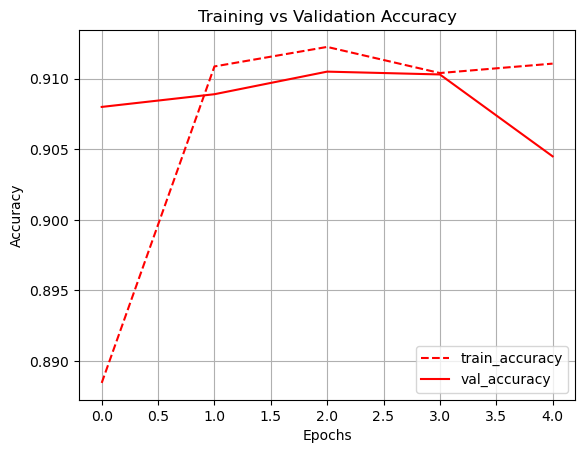

In [ ]:
from keras.datasets import mnist
from keras import models, layers
from keras.utils import to_categorical
import matplotlib.pyplot as plt

# 데이터셋 로딩
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

# 모델 정의
network = models.Sequential()
network.add(layers.Dense(512, activation='relu', input_shape=(28 * 28,)))
network.add(layers.Dense(10, activation='softmax'))

# 모델 컴파일
network.compile(optimizer='rmsprop',
                loss='categorical_crossentropy',
                metrics=['accuracy'])

# 데이터 전처리
train_images = train_images.reshape((60000, 28 * 28)).astype('float32') / 255
test_images = test_images.reshape((10000, 28 * 28)).astype('float32') / 255

train_labels = to_categorical(train_labels, 10)
test_labels = to_categorical(test_labels, 10)

# 모델 학습 + 히스토리 저장
history = network.fit(train_images, train_labels,
                        epochs=5,
                        batch_size=128,
                        validation_data=(test_images, test_labels),
                        verbose=2)

# 모델 평가
res = network.evaluate(test_images, test_labels, verbose=0)
print("정확률 =", res[1] * 100)

# Accuracy 그래프
plt.plot(history.history['accuracy'], 'r--')
plt.plot(history.history['val_accuracy'], 'r')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['train_accuracy', 'val_accuracy'])
plt.grid()
plt.show()


## C.

- 은닉층 변경 후 성능 및 그래프 비교

> 첫번째 부분은 128개 뉴런

> 두번째 부분을 32개 뉴런

> 출력 부분은 원래대로 유지하며, 수정된 프로그램으로 history graph를 생성

Epoch 1/5
469/469 - 7s - 14ms/step - accuracy: 0.8771 - loss: 0.4272 - val_accuracy: 0.9067 - val_loss: 0.3266
Epoch 2/5
469/469 - 6s - 13ms/step - accuracy: 0.9054 - loss: 0.3388 - val_accuracy: 0.8620 - val_loss: 0.4702
Epoch 3/5
469/469 - 6s - 13ms/step - accuracy: 0.8966 - loss: 0.3790 - val_accuracy: 0.9024 - val_loss: 0.3588
Epoch 4/5
469/469 - 6s - 13ms/step - accuracy: 0.8823 - loss: 0.4715 - val_accuracy: 0.8584 - val_loss: 0.5240
Epoch 5/5
469/469 - 7s - 16ms/step - accuracy: 0.8621 - loss: 0.6269 - val_accuracy: 0.8513 - val_loss: 0.7516
정확률 = 85.13000011444092


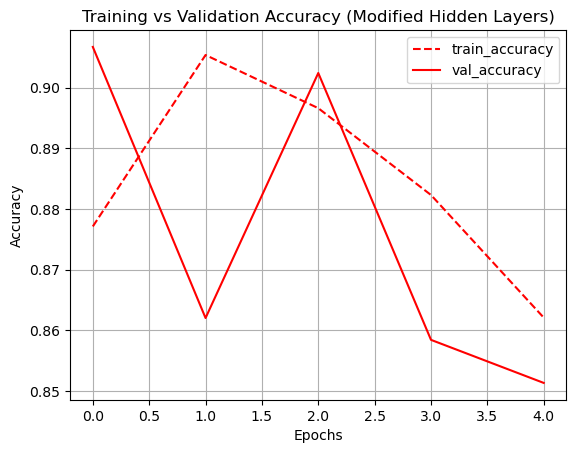

In [4]:
from keras.datasets import mnist
from keras import models, layers
from keras.utils import to_categorical
import matplotlib.pyplot as plt

# 데이터셋 로딩
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

# 모델 정의
network = models.Sequential()
network.add(layers.Dense(128, activation='relu', input_shape=(28 * 28,)))  
network.add(layers.Dense(32, activation='relu'))                          
network.add(layers.Dense(10, activation='softmax'))                        

# 모델 컴파일
network.compile(optimizer='rmsprop',
                loss='categorical_crossentropy',
                metrics=['accuracy'])

# 데이터 전처리
train_images = train_images.reshape((60000, 28 * 28)).astype('float32') / 255
test_images = test_images.reshape((10000, 28 * 28)).astype('float32') / 255

train_labels = to_categorical(train_labels, 10)
test_labels = to_categorical(test_labels, 10)

# 모델 학습
history = network.fit(train_images, train_labels,
                    epochs=5,
                    batch_size=128,
                    validation_data=(test_images, test_labels),
                    verbose=2)

# 모델 평가
res = network.evaluate(test_images, test_labels, verbose=0)
print("정확률 =", res[1] * 100)

# Accuracy 그래프
plt.plot(history.history['accuracy'], 'r--')
plt.plot(history.history['val_accuracy'], 'r')
plt.title('Training vs Validation Accuracy (Modified Hidden Layers)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['train_accuracy', 'val_accuracy'])
plt.grid()
plt.show()


---

# 2. 강의자료 8장 36~38쪽에 나와있는 Cifar-10 영상 인식 프로그램을 수행

- 데이터 읽는 부분을 한번만 수행하도록 36페이지 우선 실행

In [ ]:
import tensorflow as tf
from tensorflow import keras
from keras import models
from keras import layers
from keras.utils import to_categorical

# 관련 패키지
import numpy as np
import matplotlib.pyplot as plt

# 영상 파일 읽기
cifar10 = keras.datasets.cifar10
(train_images, train_labels), (test_images, test_labels) = cifar10.load_data()

# 영상 데이터를 [0, 1] 범위로 바꾸기
train_images = train_images / 255.0
test_images = test_images / 255.0

train_labels = to_categorical(train_labels, 10)
test_labels = to_categorical(test_labels, 10)

In [ ]:
# 모델 정의
model = models.Sequential()
model.add(layers.Conv2D(32, (3,3), padding="SAME", activation='relu', input_shape=(32,
32, 3)))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Conv2D(64, (3,3), padding="SAME", activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Conv2D(64, (3,3), padding="SAME", activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))

# 모델 컴파일
model.compile(optimizer='rmsprop',
            loss='categorical_crossentropy',
            metrics=['accuracy'])

# 파라미터 수 읽기
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

- epochs = 15로 변경하여 수행

In [ ]:
batch_size = 64
early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=10)

model.fit(train_images, train_labels,
        batch_size=batch_size,
        validation_split=0.1,
        epochs=15, 
        callbacks=[early_stop])

test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)
print('\n테스트 정확도:', test_acc)


Epoch 1/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.3062 - loss: 1.8975 - val_accuracy: 0.2750 - val_loss: 2.6665
Epoch 2/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - accuracy: 0.5324 - loss: 1.3310 - val_accuracy: 0.4830 - val_loss: 1.6076
Epoch 3/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.5951 - loss: 1.1724 - val_accuracy: 0.4888 - val_loss: 1.6632
Epoch 4/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - accuracy: 0.5998 - loss: 1.2372 - val_accuracy: 0.3948 - val_loss: 2.7487
Epoch 5/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - accuracy: 0.5783 - loss: 1.5758 - val_accuracy: 0.4628 - val_loss: 3.3605
Epoch 6/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.5257 - loss: 3.0610 - val_accuracy: 0.4448 - val_loss: 7.9320
Epoch 7/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - accuracy: 0.4775 - loss: 7.6858 - val_accuracy: 0.3410 - val_loss: 37.2235
Epoch 8/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 17ms/step - accuracy: 0.4167 - loss: 23.4136 

---

# 3. 요구사항에 따라 위에서 진행한 2.의 프로그램을 확장하여 구현 및 결과의 정확도 측정

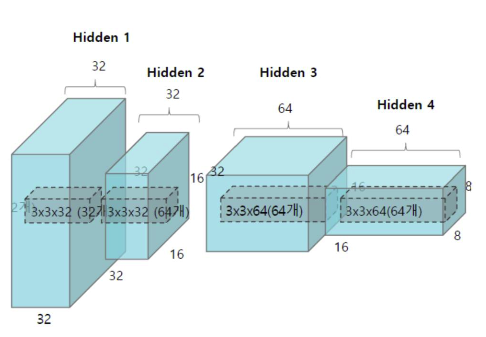

- Hidden 1과 Hidden 3를 그림과 같이 두 단계로 확장
- Convolution을 반복 수행하고, max pooling은 두번째 단계에서만 수행

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_18 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 64)             │       262,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 402,282 (1.53 MB)

 Trainable params: 402,282 (1.53 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
704/704 - 18s - 26ms/step - accuracy: 0.3466 - loss: 1.8290 - val_accuracy: 0.3116 - val_loss: 2.3855
Epoch 2/15
704/704 - 16s - 22ms/step - accuracy: 0.3846 - loss: 3.5235 - val_accuracy: 0.1864 - val_loss: 12.0268
Epoch 3/15
704/704 - 16s - 22ms/step - accuracy: 0.3081 - loss: 797.4395 - val_accuracy: 0.2290 - val_loss: 7243.0962
Epoch 4/15
704/704 - 16s - 23ms/step - accuracy: 0.2629 - loss: 160898.9688 - val_accuracy: 0.1764 - val_loss: 510448.1875
Epoch 5/15
704/704 - 16s - 23ms/step - accuracy: 0.2199 - loss: 1524774.1250 - val_accuracy: 0.1760 - val_loss: 10054148.0000
Epoch 6/15
704/704 - 16s - 23ms/step - accuracy: 0.2430 - loss: 12907713.0000 - val_accuracy: 0.2036 - val_loss: 34751544.0000
Epoch 7/15
704/704 - 16s - 23ms/step - accuracy: 0.2443 - loss: 58322608.0000 - val_accuracy: 0.2194 - val_loss: 128177416.0000
Epoch 8/15
704/704 - 16s - 22ms/step - accuracy: 0.2460 - loss: 207820256.0000 - val_accuracy: 0.1698 - val_loss: 758021888.0000
Epoch 9/15
704/704 - 1

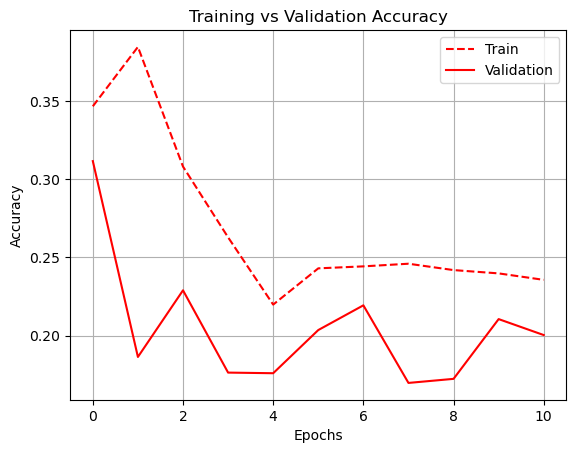

In [19]:
import tensorflow as tf
from tensorflow import keras
from keras import models, layers
from keras.utils import to_categorical
import numpy as np
import matplotlib.pyplot as plt


(train_images, train_labels), (test_images, test_labels) = keras.datasets.cifar10.load_data()

train_images = train_images / 255.0
test_images = test_images / 255.0

train_labels = to_categorical(train_labels, 10)
test_labels = to_categorical(test_labels, 10)

model = models.Sequential()


# Hidden 1: Conv(32) → Conv(32) -> 두 단계로 확장
model.add(layers.Conv2D(32, (3, 3), activation='relu', padding='SAME', input_shape=(32, 32, 3)))
model.add(layers.Conv2D(32, (3, 3), activation='relu', padding='SAME'))

# Hidden 2: Conv(64) → MaxPooling -> 두 번째 단계에서 max pooling 수행
model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='SAME'))
model.add(layers.MaxPooling2D((2, 2)))

# Hidden 3: Conv(64) → Conv(64) -> 두 단계로 확장
model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='SAME'))
model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='SAME'))

# Hidden 4: Conv(64) → MaxPooling -> 두 번째 단계에서 max pooling 수행
model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='SAME'))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))


model.compile(optimizer='rmsprop',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

batch_size = 64
early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=10)

history = model.fit(train_images, train_labels,
                    batch_size=batch_size,
                    validation_split=0.1,
                    epochs=15,
                    callbacks=[early_stop],
                    verbose=2)

test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)
print('\n테스트 정확도:', test_acc)

plt.plot(history.history['accuracy'], 'r--')
plt.plot(history.history['val_accuracy'], 'r')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.grid()
plt.show()
